In [ ]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import sphWarpCore as sph
from sphWarpCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np

# custom SPH libraries
from integrators.integration import *
from sphWarpCore import *

# This library
from compressibleSPH import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}


In [5]:
from compressibleSPH.enumTypes import *

nx = 128
gamma = 1.4
# leftState = sodInitialState(1, 1, 0)
# rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 1
smoothIC = True
timeLimit = 0.15

rho_I = 1.0
p_I = 1.0
rho_II = 0.125
p_II = 0.1
rho_III = 1.0
p_III = 0.1


# from compressibleSPH.configurations.simulationConfig import SimulationConfig, buildConfig
# from compressibleSPH.schemeBuilder import buildScheme


L = 1
dx = L/nx
aspect = 2
band = 20

dim = 2
n_h = 4

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()


domain = buildDomainDescription(l = 1, dim = dim, periodic = True, device = device, dtype = dtype)
domain.min[0] = 0
domain.max[0] = 14
domain.min[1] = -3
domain.max[1] = 3

config = SimulationConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.B7,
    targetNeighbors = n_h_to_nH(n_h, dim),
    supportMode = SupportScheme.Gather,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = True,
    cflFactor=0.3,
    verletScale=1.0
)
config.nx = nx
config.dx = 1 / config.nx

scheme = CompressibleSPHScheme.CRKSPH
# SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('MonaghanCompressibleSPH')
# SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('compSPH')
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)

compressibleSPHConfig = SimulationConfig()
compressibleSPHConfig.gamma = gamma
compressibleSPHConfig.rho0 = 1
compressibleSPHConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
# compressibleSPHConfig.viscositySwitchParams.scheme = ViscositySwitch.CullenHopkins
compressibleSPHConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch
# compressibleSPHConfig.viscositySwitchParams.correctVelocityGradient = True
# compressibleSPHConfig.adaptiveSupportCorrections = False

display(compressibleSPHConfig)

# diffusionParams = DiffusionParameters()
# diffusionParams.c_s = 1
# diffusionParams.C_l = 1
# diffusionParams.C_q = 2
# diffusionParams.Cu_l = 1
# diffusionParams.Cu_q = 2
# diffusionParams.K = 1.0
# diffusionParams.thermalConductivity = 0.5
# diffusionParams.viscosityTerm = ViscosityTerms.Monaghan1992.value
# diffusionParams.thermalConducitiyTerm = ViscosityTerms.Price2012_98.value
# diffusionParams.scaleBeta = False
# diffusionParams.monaghanSwitch = True
# diffusionParams.correctXi = True

# compressibleSPHConfig = CompressibleSPHConfig(
#     gamma = gamma,
#     rho0 = leftState.rho,
#     diffusionParams = diffusionParams,
# )
# integrator = getIntegrator(config.integrationScheme)

# compressibleSPHConfig.crkViscosityParams.enableCRKLimiter = False


CRKSPHConfig(gamma=1.4, backgroundPressure=0.0, rho0=1, adaptiveSupportScheme=<AdaptiveSupportScheme.Owen: 2>, adaptiveSupportIterations=1, adaptiveSupportThreshold=0.001, adaptiveSupportCorrections=True, diffusionParams=DiffusionParameters(
	c_s=1,
	C_l=1,
	C_q=1,
	Cu_l=1,
	Cu_q=1,
	K=1.0,
	thermalConductivity=0.5,
	viscosityTerm=3,
	thermalConducitiyTerm=7,
	scaleBeta=False,
	monaghanSwitch=True,
	correctXi=True,
), viscositySwitchParams=ViscositySwitchConfig(scheme=<ViscositySwitch.NoneSwitch: 6>, limitXi=True, correctVelocityGradient=False, divergenceScheme='naive', alpha_min=0.02, alpha_max=2.0, beta_c=0.7, beta_d=0.05, beta_xi=2.0), schemeName='CRKSPH', boundaryConditions=[], energyScheme=<EnergyScheme.CRK: 5>, crkViscosityParams=CRKViscosity(
	eta_fold=0.2,
	eta_crit=0.3333333,
	enableCRKLimiter=True,
	enableVanLeerLimiter=True,
	forceVanLeerOff=False,
	forceVanLeerOn=False,
), compatibleEnergy=True)

In [6]:
# compSystem = buildSedov(
#     SimulationSystem, SimulationState, 
#     config = config,
#     nx = nx, dim = dim, domainExtent = L, 
#     periodicDomain = True, 
#     rho0 = rho0, E0 = E0, 
#     initialization = 'quadrant', 
#     gamma = gamma, kernel = config.kernel, 
#     targetNeighbors = config.targetNeighbors, 
#     dtype = config.dtype, device = config.device)

In [11]:
import numpy as np

def splitDomain(split_x, split_y, domain, nx):
    lx = domain.max[0] - domain.min[0]
    dx = lx / nx
    ly = domain.max[1] - domain.min[1]
    dy = ly / nx

    splitx_ = (split_x - domain.min[0]) / dx
    splity_ = (split_y - domain.min[1]) / dy

    rounded_splitx_ = torch.round(splitx_).long()
    rounded_splity_ = torch.round(splity_).long()

    splitx = rounded_splitx_ * dx + domain.min[0]
    splity = rounded_splity_ * dy + domain.min[1]

    return splitx.cpu().item(), splity.cpu().item()


def maskParticles(particles, split_x, split_y, domain, nx):
    if isinstance(split_x, list):
        splitXLower, splitYLower = splitDomain(split_x[0], split_y[0], domain, nx)
        splitXUpper, splitYUpper = splitDomain(split_x[1], split_y[1], domain, nx)

        A_1 = (particles.positions[:, 0] < splitXLower) & (particles.positions[:, 1] < splitYLower)
        A_2 = (particles.positions[:, 0] >= splitXUpper) & (particles.positions[:, 1] < splitYLower)
        A_3 = (particles.positions[:, 0] < splitXLower) & (particles.positions[:, 1] >= splitYUpper)
        A_4 = (particles.positions[:, 0] >= splitXUpper) & (particles.positions[:, 1] >= splitYUpper)
        maskA = torch.logical_or(torch.logical_or(A_1, A_2), torch.logical_or(A_3, A_4))

        B_1 = (particles.positions[:, 0] < splitXLower) & (particles.positions[:, 1] >= splitYLower)
        B_2 = (particles.positions[:, 0] < splitXLower) & (particles.positions[:, 1] < splitYUpper)
        B_3 = (particles.positions[:, 0] >= splitXUpper) & (particles.positions[:, 1] >= splitYLower)
        B_4 = (particles.positions[:, 0] >= splitXUpper) & (particles.positions[:, 1] < splitYUpper)
        maskB = torch.logical_or(torch.logical_and(B_1, B_2), torch.logical_and(B_3, B_4))

        C_1 = (particles.positions[:, 0] >= splitXLower) & (particles.positions[:, 1] < splitYLower)
        C_2 = (particles.positions[:, 0] < splitXUpper) & (particles.positions[:, 1] < splitYLower)
        C_3 = (particles.positions[:, 0] >= splitXLower) & (particles.positions[:, 1] >= splitYUpper)
        C_4 = (particles.positions[:, 0] < splitXUpper) & (particles.positions[:, 1] >= splitYUpper)
        maskC = torch.logical_or(torch.logical_and(C_1, C_2), torch.logical_and(C_3, C_4))

        mask = torch.ones_like(particles.positions[:, 0], dtype=torch.int64, device=device)*3
        mask[maskA] = 0
        mask[maskB] = 2
        mask[maskC] = 1

        return mask, [splitXLower, splitXUpper], [splitYLower, splitYUpper]

    else:

        splitx, splity = splitDomain(split_x, split_y, domain, nx)

        maskA = (particles.positions[:, 0] < splitx) & (particles.positions[:, 1] < splity)
        maskB = (particles.positions[:, 0] >= splitx) & (particles.positions[:, 1] < splity)
        maskC = (particles.positions[:, 0] < splitx) & (particles.positions[:, 1] >= splity)
        maskD = (particles.positions[:, 0] >= splitx) & (particles.positions[:, 1] >= splity)

        mask = torch.zeros_like(particles.positions[:, 0], dtype=torch.int64, device=device)
        mask[maskA] = 0
        mask[maskB] = 1
        mask[maskC] = 2
        mask[maskD] = 3

        return mask, splitx, splity

def maskParticlesSymmetric(particles, split_x, split_y, domain, nx):
    return maskParticles(particles, [split_x, domain.max[0] - split_x], [split_y, domain.max[1] - split_y], domain, nx)


In [12]:
from compressibleSPH.utils.sampling import ParticleSet

def sampleRegions(domain, nx, targetNeighbors, splitX, splitY, jitter = 0.0):
    print(f'Sampling regions with nx = {nx}, splitX = {splitX}, splitY = {splitY}, jitter = {jitter}')
    if isinstance(nx, int):
        particles = sampleRegularParticles(nx, domain, targetNeighbors, jitter = jitter)

        # split_x, split_y = splitDomain(splitX, splitY, domain, nx)
        mask, split_x, split_y = maskParticles(particles, splitX, splitY, domain, nx)

        particlesA = ParticleSet(
            positions = particles.positions[mask == 0],
            supports = particles.supports[mask == 0],
            masses = particles.masses[mask == 0],
            densities = particles.densities[mask == 0]
        ) 
        particlesB = ParticleSet(
            positions = particles.positions[mask == 1],
            supports = particles.supports[mask == 1],
            masses = particles.masses[mask == 1],
            densities = particles.densities[mask == 1]
        ) 
        particlesC = ParticleSet(
            positions = particles.positions[mask == 2],
            supports = particles.supports[mask == 2],
            masses = particles.masses[mask == 2],
            densities = particles.densities[mask == 2]
        ) 
        particlesD = ParticleSet(
            positions = particles.positions[mask == 3],
            supports = particles.supports[mask == 3],
            masses = particles.masses[mask == 3],
            densities = particles.densities[mask == 3]
        )

        return particlesA, particlesB, particlesC, particlesD, split_x, split_y
    else:
        particlesA = sampleRegularParticles(nx[0], domain, targetNeighbors, jitter = jitter)
        particlesB = sampleRegularParticles(nx[1], domain, targetNeighbors, jitter = jitter)
        particlesC = sampleRegularParticles(nx[2], domain, targetNeighbors, jitter = jitter)
        particlesD = sampleRegularParticles(nx[3], domain, targetNeighbors, jitter = jitter)

        # splitx, splity = splitDomain(splitX, splitY, domain, np.min(nx))

        maskA, splitx, splity = maskParticles(particlesA, splitX, splitY, domain, np.min(nx))
        maskB, *_ = maskParticles(particlesB, splitX, splitY, domain, np.min(nx))
        maskC, *_ = maskParticles(particlesC, splitX, splitY, domain, np.min(nx))
        maskD, *_ = maskParticles(particlesD, splitX, splitY, domain, np.min(nx))

        particlesA = ParticleSet(
            positions = particlesA.positions[maskA == 0],
            supports = particlesA.supports[maskA == 0],
            masses = particlesA.masses[maskA == 0],
            densities = particlesA.densities[maskA == 0]
        ) 
        particlesB = ParticleSet(
            positions = particlesB.positions[maskB == 1],
            supports = particlesB.supports[maskB == 1],
            masses = particlesB.masses[maskB == 1],
            densities = particlesB.densities[maskB == 1]
        ) 
        particlesC = ParticleSet(
            positions = particlesC.positions[maskC == 2],
            supports = particlesC.supports[maskC == 2],
            masses = particlesC.masses[maskC == 2],
            densities = particlesC.densities[maskC == 2]
        )
        particlesD = ParticleSet(
            positions = particlesD.positions[maskD == 3],
            supports = particlesD.supports[maskD == 3],
            masses = particlesD.masses[maskD == 3],
            densities = particlesD.densities[maskD == 3]
        )

        return particlesA, particlesB, particlesC, particlesD, splitx, splity
    
def sampleRegionsSymmetric(domain, nx, targetNeighbors, splitX, splitY, jitter = 0.0):
    lx = domain.max[0].item() - domain.min[0].item()
    ly = domain.max[1].item() - domain.min[1].item()

    minX = domain.min[0].item()
    minY = domain.min[1].item()
    maxX = domain.max[0].item()
    maxY = domain.max[1].item()

    splitXUpper = minX + (maxX - minX) * (1 - (splitX - minX) / (maxX - minX))
    splitYUpper = minY + (maxY - minY) * (1 - (splitY - minY) / (maxY - minY))

    return sampleRegions(domain, nx, targetNeighbors, [splitX, splitXUpper], [splitY, splitYUpper], jitter = jitter)


def plotDomain(axis, domain):
    axis.set_xlim(domain.min[0].cpu(), domain.max[0].cpu())
    axis.set_ylim(domain.min[1].cpu(), domain.max[1].cpu())
    axis.set_aspect('equal')

    axis.plot([domain.min[0].cpu(), domain.max[0].cpu()], [domain.min[1].cpu(), domain.min[1].cpu()], 'k-')
    axis.plot([domain.min[0].cpu(), domain.max[0].cpu()], [domain.max[1].cpu(), domain.max[1].cpu()], 'k-')
    axis.plot([domain.min[0].cpu(), domain.min[0].cpu()], [domain.min[1].cpu(), domain.max[1].cpu()], 'k-')
    axis.plot([domain.max[0].cpu(), domain.max[0].cpu()], [domain.min[1].cpu(), domain.max[1].cpu()], 'k-')

def mergeParticles(particles_list):
    positions = torch.cat([p.positions for p in particles_list], dim=0)
    supports = torch.cat([p.supports for p in particles_list], dim=0)
    masses = torch.cat([p.masses for p in particles_list], dim=0)
    densities = torch.cat([p.densities for p in particles_list], dim=0)
    index = torch.cat([torch.ones_like(p.masses) * i for i, p in enumerate(particles_list)], dim=0)

    return ParticleSet(
        positions = positions,
        supports = supports,
        masses = masses,
        densities = densities
    ), index


def computeNs(domain, nx, band, shortEdge = True):    
    periodicity = domain.periodic
    dxs = []
    for d in range(domain.dim):
        l = domain.max[d] - domain.min[d]
        dx = l/(nx if periodicity[d] else nx-1)
        # x = torch.linspace(domain.min[d] + offset, domain.max[d] - offset, nx + band * 2, device = domain.min.device, dtype = domain.min.dtype)
        # spaces.append(x)
        dxs.append(dx)

    spaces = []
    if shortEdge:
        dx = torch.min(torch.tensor(dxs))
    else:
        dx = torch.max(torch.tensor(dxs))
    # print(dxs, dx, nx)
    ns = []
    for d in range(domain.dim):
        l = domain.max[d] - domain.min[d]
        nd = (torch.ceil(l/dx)).to(torch.int32)
        dn = l / (nd if periodicity[d] else nd-1)
        offset = dx/2 if periodicity[d] else 0
        offset -= dx * band

        # print(f'Dimension {d}: l: {l}, dx: {dx}, nd: {nd}, dn: {dn}, offset: {offset}')
        x = torch.linspace(domain.min[d] + offset, domain.max[d] - offset, nd + band * 2, device = domain.min.device, dtype = domain.min.dtype)
        spaces.append(x)
        ns.append(nd + band * 2)
    
    return ns

In [13]:
import math
splitLineX = 1
splitLineY = -1.5

# region 0 and 2 correspond to I
# region 1 is II
# region 3 is III
# regions I and III are high density
# region II is low density
# to sample we flip it around with sampling II at nx and sampling I and III at higher rates
# the target density for I and III is 1, so the ratio is 8, i.e., nx * sqrt(8)

particlesA, particlesB, particlesC, particlesD, splitx, splity = sampleRegionsSymmetric(config.domain, [nx*math.sqrt(8), nx, nx*math.sqrt(8), nx * math.sqrt(8)], config.targetNeighbors, splitLineX, splitLineY)

print(f'Particles in region A: {len(particlesA.masses)}')
print(f'Particles in region B: {len(particlesB.masses)}')
print(f'Particles in region C: {len(particlesC.masses)}')
print(f'Particles in region D: {len(particlesD.masses)}')

particles, setIndex = mergeParticles([particlesA, particlesB, particlesC, particlesD])


Sampling regions with nx = [362.03867196751236, 128, 362.03867196751236, 362.03867196751236], splitX = [1, 13.0], splitY = [-1.5, 1.5], jitter = 0.0
Particles in region A: 21476
Particles in region B: 16448
Particles in region C: 21358
Particles in region D: 131587


In [14]:
print(particles.positions.shape)

torch.Size([190869, 2])


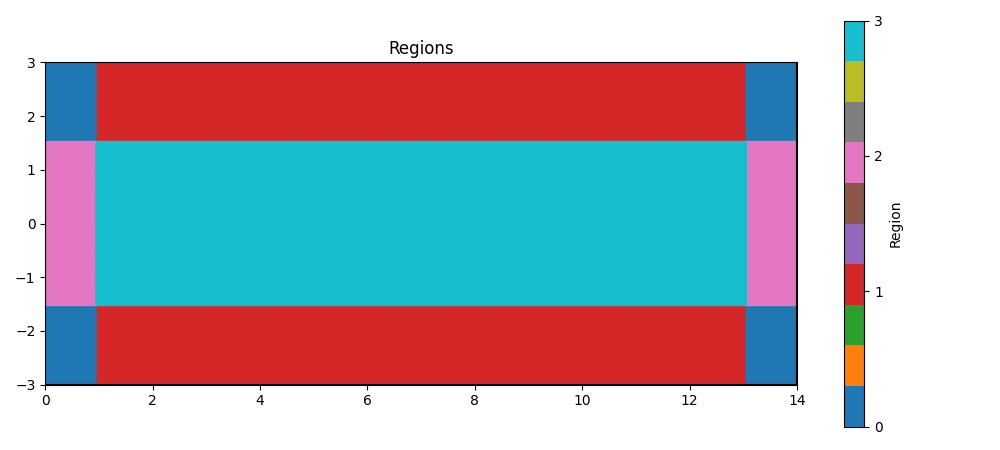

In [15]:

fig, axis = plt.subplots(1, 1, figsize=(10, 4.5), squeeze=False, sharex=True, sharey=True)

sc = axis[0,0].scatter(particles.positions[:, 0].cpu(), particles.positions[:, 1].cpu(), c = setIndex.cpu(), marker = '.', cmap = 'tab10')
fig.colorbar(sc, ax=axis[0,0], ticks=[0, 1, 2, 3], label='Region')
# axis[0,0].scatter(particlesB.positions[:, 0].cpu(), particlesB.positions[:, 1].cpu(), s = 4, marker = '.')
# axis[0,0].scatter(particlesC.positions[:, 0].cpu(), particlesC.positions[:, 1].cpu(), s = 4, marker = '.')
# axis[0,0].scatter(particlesD.positions[:, 0].cpu(), particlesD.positions[:, 1].cpu(), s = 4, marker = '.')

axis[0,0].set_title('Regions')

plotDomain(axis[0,0], domain)

fig.tight_layout()

In [16]:


# config.domain.min[0] = -L/2/aspect
# config.domain.max[0] = L/2/aspect
# config.domain.min[1] = 0 - band * dx
# config.domain.max[1] = L + band * dx
# particles_ = sampleRegularParticles(nx, config.domain, config.targetNeighbors)
particles_, setIndex = mergeParticles([particlesA, particlesB, particlesC, particlesD])
print(f"Sampled {particles_.positions.shape[0]} particles.")

particles_.masses[:] = particles_.masses.min() # we oversample the density regions with rho = 1 so we need to use the min here
# domain = buildDomainDescription(domainExtent * 1.5, dim, periodic = periodicDomain, device = device, dtype = dtype)
particles_ = particles_._replace(masses = particles_.masses * compressibleSPHConfig.rho0)


print(f"Sampled {particles_.positions.shape[0]} particles. From {particles_.positions.min(dim=0).values} to {particles_.positions.max(dim=0).values}")
print(f' Support: Min: {particles_.supports.min().item()}, Max: {particles_.supports.max().item()}, Mean: {particles_.supports.mean().item()}')

particles = SimulationState(
    positions = particles_.positions,
    supports = particles_.supports,
    masses = particles_.masses,
    densities = particles_.densities,
    velocities = torch.zeros_like(particles_.positions),
    
    kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter = particles_.positions.shape[0],
    
    internalEnergies = None,
    totalEnergies = None,
    entropies = None,
    pressures = None,
    soundspeeds = None,

    divergence=torch.zeros_like(particles_.densities),
    alpha0s= torch.ones_like(particles_.densities),
    alphas= torch.ones_like(particles_.densities),
)


densities = warpOperation(
    particles, 
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Density,
        supportMode = SupportScheme.Gather,
        gradientMode = config.gradientMode,
        laplacianMode = config.laplacianMode,
    ),
    domain = config.domain,
)
particles.densities = densities

compressibleSPHConfigAdaptiveH = CompressibleSPHConfig(
    adaptiveSupportIterations=16,
    adaptiveSupportThreshold=1e-3,
    adaptiveSupportScheme=AdaptiveSupportScheme.Owen,
)

from compressibleSPH.modules import *

# wrappedKernel = warpKernelToDiffSPHKernel(kernel)
# neighborhood, neighbors = evaluateNeighborhood(particles, domain, wrappedKernel, verletScale = 1.0, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
# numNeighbors = coo_to_csr(filterNeighborhoodByKind(particles, neighbors.neighbors, which = 'noghost')).rowEntries
# config = {'targetNeighbors': targetNeighbors, 'domain': domain, 'support': {'iterations': 16, 'scheme': 'Monaghan'}, 'neighborhood': {'algorithm': 'compact'}}
# rho, h, rhos, hs, neighborhood = evaluateOptimalSupport(particles, wrappedKernel, neighborhood, SupportScheme.Gather, config)

rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather, compParams = compressibleSPHConfigAdaptiveH)
# particleState.supports = h_optimal

# particles.densities = rho_optimal
# particles.supports = h_optimal

print(f' Support After Optimization: Min: {particles.supports.min().item()}, Max: {particles.supports.max().item()}, Mean: {particles.supports.mean().item()}')

P_initial = torch.zeros_like(particles.densities)
u = 1 / (gamma - 1) * (P_initial / rho_optimal)
# A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = P_initial, rho = rho_optimal, gamma = gamma)
A_, u_, P_, c_s = idealGasEOS(A = None, u = u, P = None, rho = rho_optimal, gamma = gamma)

internalEnergy = u_ 
kineticEnergy = torch.linalg.norm(torch.zeros_like(particles.positions), dim = -1) **2/ 2
totalEnergy = (internalEnergy + kineticEnergy) * particles.masses

simulationState_ = SimulationState(
    positions = particles.positions,
    supports = particles.supports,
    masses = particles.masses,
    densities = particles.densities,        
    velocities = torch.zeros_like(particles.positions),

    kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter = particles.positions.shape[0],
    
    internalEnergies = u_,
    totalEnergies = totalEnergy,
    entropies = A_,
    pressures = P_,
    soundspeeds = c_s,

    alphas = torch.ones_like(particles.densities),
    alpha0s = torch.ones_like(particles.densities),
    divergence=torch.zeros_like(particles.densities),
)
    


adjacency = buildVerletList(simulationState_, 
                            domain = config.domain,
                            verletScale = 2**(1/config.dim), supportMode = config.supportMode)

compressibleSystem = SimulationSystem(
    state=simulationState_, 
    adjacency = adjacency, 
    domain = config.domain)

# config.domain.min[0] = -L/2/aspect
# config.domain.max[0] = L/2/aspect
# config.domain.min[1] = 0 - 2*band * dx
# config.domain.max[1] = L + 2*band * dx

density = warpOperation(
    simulationState_, 
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Density,
        supportMode = SupportScheme.Gather,
        gradientMode = config.gradientMode,
        laplacianMode = config.laplacianMode,
    ),
    domain = config.domain,
)

print(f"Density: Min: {density.min().item()}, Max: {density.max().item()}, Mean: {density.mean().item()}")

Sampled 190869 particles.
Sampled 190869 particles. From tensor([ 0.0083, -2.9917], device='cuda:0') to tensor([13.9917,  2.9917], device='cuda:0')
 Support: Min: 0.06629125773906708, Max: 0.1875, Mean: 0.07673633843660355
Module sphWarpCore.radiusSearch.wp_compactHash e67fccd load on device 'cuda:0' took 3.55 ms  (cached)
Module sphWarpCore.operations_grid.wp_density_grid 82cf6d3 load on device 'cuda:0' took 7.85 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_psi 8875fe6 load on device 'cuda:0' took 11.76 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_psi0 37e5819 load on device 'cuda:0' took 8.32 ms  (cached)
Module sphWarpCore.operations.wp_density f0357bf load on device 'cuda:0' took 5.37 ms  (cached)
 Support After Optimization: Min: 0.06783495843410492, Max: 0.19216004014015198, Mean: 0.07843349128961563
Density: Min: 0.12513954937458038, Max: 1.0029754638671875, Mean: 0.9246445298194885


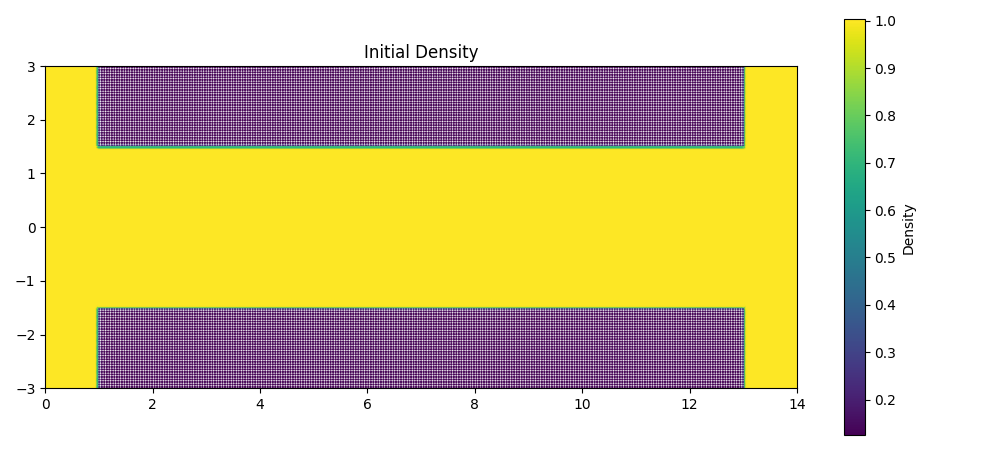

In [17]:
fig, axis = plt.subplots(1, 1, figsize=(10, 4.5), squeeze=False, sharex=True, sharey=True)
scatter = axis[0,0].scatter(simulationState_.positions[:, 0].cpu(), simulationState_.positions[:, 1].cpu(), c = density.cpu(), s = 0.5)
fig.colorbar(scatter, ax=axis[0,0], label='Density')
axis[0,0].set_title('Initial Density')

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].cpu(), config.domain.max[0].cpu())
    ax.set_ylim(config.domain.min[1].cpu(), config.domain.max[1].cpu())

fig.tight_layout()

In [18]:
particles = compressibleSystem.state

rhoInitial = particles.densities.clone()
Pi = particles.pressures.clone()

regionI = torch.logical_or(particles.positions[:,0] <= 1.0, particles.positions[:,0] >= 13)
regionII = torch.logical_and(~regionI, particles.positions[:,1].abs() >= 1.5)
regionIII = torch.logical_and(~regionI, particles.positions[:,1].abs() < 1.5)

rhoInitial[regionI] = rho_I
Pi[regionI] = p_I
rhoInitial[regionII] = rho_II
Pi[regionII] = p_II
rhoInitial[regionIII] = rho_III
Pi[regionIII] = p_III

densityRatio = 1 # equal mass sampling, so we don't need to adjust the masses 
# densityRatio = rhoInitial / particles.densities # for equal spacing sampling, we need to adjust the masses to achieve the target density


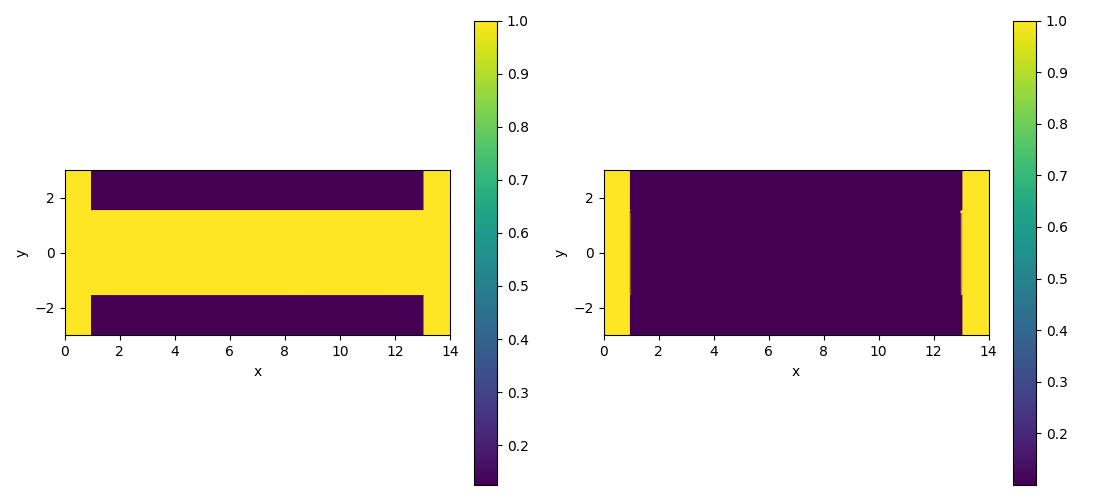

In [19]:
fig, axis = plt.subplots(1, 2, figsize=(11,5), squeeze=False)

sc = axis[0,0].scatter(particles.positions[:,0].cpu(), particles.positions[:,1].cpu(), c = rhoInitial.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,0])

sc = axis[0,1].scatter(particles.positions[:,0].cpu(), particles.positions[:,1].cpu(), c = Pi.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,1])

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].item(), config.domain.max[0].item())
    ax.set_ylim(config.domain.min[1].item(), config.domain.max[1].item())
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig.tight_layout()

In [20]:
Lx = config.domain.max[0] - config.domain.min[0]
Ly = config.domain.max[1] - config.domain.min[1]
aspect = Ly / Lx

dx = Lx / (nx / aspect)
dy = Ly / nx

area = Lx * Ly / nx**2 * aspect


In [21]:
# Pinitial = Pi
# rhoInitial = rho_y


A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = Pi, rho = rhoInitial, gamma = gamma)
# v_initial = torch.zeros_like(particles_l.positions)

vInitial = torch.zeros_like(particles.positions)
internalEnergy = u_ 
kineticEnergy = torch.linalg.norm(vInitial, dim = -1) **2/ 2
totalEnergy = (internalEnergy + kineticEnergy) * particles.masses

particles.internalEnergies = u_
particles.totalEnergies = totalEnergy
particles.pressures = P_
particles.soundspeeds = c_s
particles.velocities = vInitial
particles.densities = rhoInitial
# particles.masses = area * rhoInitial

compressibleSystem = SimulationSystem(
    state=particles, 
    adjacency = adjacency, 
    domain = config.domain)

In [22]:

# rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather, compParams = compressibleSPHConfig)

# compressibleSystem.state.supports = h_optimal


In [23]:

adjacency = buildVerletList(
    compressibleSystem.state, 
    config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

apparentVolume, compressibleSystem.state.densities, crkState = computeCRKFactors(compressibleSystem.state, config.domain, config.kernel, adjacency = adjacency)

Module sphWarpCore.crk.crk_volume 793e787 load on device 'cuda:0' took 31.12 ms  (cached)
Module sphWarpCore.crk.crk_moments 89bc989 load on device 'cuda:0' took 11.46 ms  (cached)
Module sphWarpCore.crk.crk_density 06a7669 load on device 'cuda:0' took 6.71 ms  (cached)


In [24]:
enforceDirichlet(compressibleSystem.state, compressibleSystem.t, config.dt, config, compressibleSPHConfig)

In [30]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, DivergingColorMap, Mapping
markerSize = 12.5
plotter = visualize(
    particleState = compressibleSystem.state,
    domain = config.domain,
    quantities = {
        "A": compressibleSystem.state.densities,
        "B": h_optimal,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "Densities",
            # mapping = Mapping.L2,
            # plottingOperation = OperationProperties(
            #     kernel = config.kernel,
            #     operation = WarpOperation.Curl,
            #     supportMode = SupportScheme.Gather,
            #     gradientMode = config.gradientMode,
            # ),
            # gridVisualization = GridVisualization(
            #     resolution = 256,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap = True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "Support Radius",
            # gridVisualization = GridVisualization(
            #     resolution = 1024,
            # ),
            # vMin=0.95,
            # vMax=2.05
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (8,7),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)

RFBOutputContext()

In [31]:
from warpPlot import *

In [32]:
KE = (compressibleSystem.state.masses * torch.linalg.norm(compressibleSystem.state.velocities, dim = -1)**2 / 2).sum()
IE = (compressibleSystem.state.masses * compressibleSystem.state.internalEnergies).sum()
TE = (compressibleSystem.state.masses * (compressibleSystem.state.internalEnergies + torch.linalg.norm(compressibleSystem.state.velocities, dim = -1)**
2)).sum()
print(f"Initial KE: {KE}, IE: {IE}, TE: {TE}, TE+PE: {TE}")

nonzeroEnergyMask = compressibleSystem.state.internalEnergies > 1e-8
print(f"Nonzero internal energy particles: {nonzeroEnergyMask.sum()} / {compressibleSystem.state.internalEnergies.shape[0]}")

Initial KE: 0.0, IE: 47.70599365234375, TE: 47.70599365234375, TE+PE: 47.70599365234375
Nonzero internal energy particles: 190869 / 190869


In [33]:
from compressibleSPH.schemes.compSPH import compSPH_step
from compressibleSPH.modules.timestep.compressible import computeTimestep
config.dt = computeTimestep(compressibleSystem, config, compressibleSPHConfig, dt = config.dt) * 2/3
print(f"Initial timestep: {config.dt}")

Initial timestep: 0.0007333333293596903


In [34]:
runningState = compressibleSystem.initializeNewState()

In [35]:
compressibleSPHConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
# compressibleSPHConfig.viscositySwitchParams.scheme = ViscositySwitch.CullenHopkins
# schemeConfig.diffusionParams.C_q = 1.0



In [ ]:
from compressibleSPH.io import *

exportPath = prepExport('triplePoint', config, compressibleSPHConfig, scheme, export_fn)

exportSimulationSystem(exportPath, 'initialState', scheme, runningState, exportAdjacency = False, stages = None, exportStagesAdjacency = True)

In [48]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, DivergingColorMap, Mapping, CyclicColorMap
markerSize = 1
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap = True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Logarithmic,
            plotTitle = "density",
            gridVisualization = GridVisualization(
                resolution = 1024,
            ),
            vMin=0.2,
            vMax=7
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'A',
    figsize= (12,6),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:

RFBOutputContext()

In [49]:
folderName = f"triple_{getCurrentTimestamp()}"
os.makedirs(f'output/{folderName}', exist_ok = True)
plotter.export(f'output/{folderName}/frame_00000.png', dpi = 200)

In [50]:
t_limit = 1.0
# config.dt = 1e-4
nSteps = int(t_limit / config.dt)
integrator = getIntegrator(config.integrationScheme)


print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 54
print(nSteps//25)

Running with dt: 0.00025, which gives nSteps: 4000
160


In [ ]:
# os.makedirs('images/kevinHH_256_2', exist_ok = True)

t_limit = 10.0
# t_limit = 0.1
# config.dt = 1e-4
config.minDt = 1e-8
config.maxDt = 1e-3
config.dt = 2.5e-4
nSteps = int(t_limit / config.dt)
integrator = getIntegrator(config.integrationScheme)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 54
 
trajectory = []
runningState = compressibleSystem.initializeNewState()
priorStep = None
t = 0
i = 0
tq = tqdm(total = 1000, leave = True)

Running with dt: 0.00025, which gives nSteps: 28000


  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:

while t < t_limit:
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    # print(f"Step {i+1}/{nSteps}, time: {runningState.t:.4f}")
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
        priorStep = priorStep
    )
    end.record()
    torch.cuda.synchronize()
    elapsed_time_ms = begin.elapsed_time(end)
    t = result.state.t.item() if isinstance(result.state.t, torch.Tensor) else result.state.t
    tq.n = int(t / t_limit * 1000)
    i = i + 1

    densityRatio = runningState.state.densities / result.state.state.densities
    
    # if (densityRatio < 0.7).any() or (densityRatio > 1.5).any():
    #     print(f"Warning: Density ratio out of bounds at step {i}, min: {densityRatio.min().item()}, max: {densityRatio.max().item()}")
    #     break

    runningState = result.state
    priorStep = result.stages[-1]
    # config.dt = computeTimestep(runningState, config, compressibleSPHConfig, dt = config.dt) 


    kineticEnergy_ = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy_ = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy_ + thermalEnergy_

    tq.set_description(f"{i:6d}: time: {t:8.4g}/{t_limit:8.4g}, TE: {totalEnergy:.3g}, KE: {kineticEnergy_.cpu().item():.3g}, IE: {thermalEnergy_.cpu().item():.3g}, step time: {elapsed_time_ms:.3f}ms, adaptive dt: {config.dt:.3g}")
    
        
    trajectory.append((
        i,
        runningState.t,
        elapsed_time_ms,
        kineticEnergy_.cpu().item(),
        thermalEnergy_.cpu().item(),
        totalEnergy.cpu().item(),
    ))
    if (i % 10 == 0 and i > 0) or i == nSteps - 1:
        plotter.updateQuantities(
            {
                # "A": runningState.state.velocities,
                "A": runningState.state.densities,
            },
            newParticleState = runningState.state,
        )
        plotter.export(f'output/{folderName}/frame_{i:05d}.png', dpi = 300)
        # for ax in axis.flatten():
        #     ax.clear()
        # plotSod_(fig, axis, runningState.state, config, schemeConfig, config.domain, gamma, leftState, rightState, plotReference = True, plotLabels = False, scatter = True, t_ = runningState.t)
        # fig.canvas.draw()
        # fig.canvas.flush_events()
    # print(f' Supports: Min: {runningState.state.supports.min().item()}, Max: {runningState.state.supports.max().item()}, Mean: {runningState.state.supports.mean().item()}')
    
    if i % 1000 == 0:
        exportSimulationSystem(exportPath, f'state_{i:05d}', scheme, runningState, exportAdjacency = False, stages = None, exportStagesAdjacency = True)
    # break

In [ ]:

exportSimulationSystem(exportPath, 'initialState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True)

In [ ]:
result = integrator.function(
    state = runningState,
    f = fn,
    dt = config.dt,
    config = config,
    compParams = compressibleSPHConfig,
    verbose = False,
    priorStep = priorStep
)

densityRatio = runningState.state.densities / result.state.state.densities

if (densityRatio < 0.7).any() or (densityRatio > 1.5).any():
    print(f"Warning: Density ratio out of bounds at step {i}, min: {densityRatio.min().item()}, max: {densityRatio.max().item()}")

print(runningState.state.densities.max(), runningState.state.densities.min())
print(result.state.state.densities.max(), result.state.state.densities.min())

In [ ]:
from integrators.euler import updateStateEuler

halfState = runningState.initializeNewState()
halfState = updateStateEuler(halfState, priorStep.update, config.dt * 0.5, False)

In [ ]:
# halfState.adjacency = None

In [ ]:
config.verletScale

In [ ]:
stepResult = fn(halfState, config.dt * 0.5, config, compressibleSPHConfig)

In [ ]:
nnrsPrev = runningState.adjacency.numNeighbors
print(f'Number of neighbors: min {nnrsPrev.min().item()}, max {nnrsPrev.max().item()}, mean {nnrsPrev.to(torch.float32).mean().item()}')
nnrsCurr = stepResult[1].numNeighbors
print(f'Number of neighbors: min {nnrsCurr.min().item()}, max {nnrsCurr.max().item()}, mean {nnrsCurr.to(torch.float32).mean().item()}')

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(11,10), squeeze=False)
sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu(), runningState.state.positions[:,1].cpu(), c = nnrsPrev.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,0])
sc = axis[0,1].scatter(stepResult[2].positions[:,0].cpu(), stepResult[2].positions[:,1].cpu(), c = nnrsCurr.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,1])
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].item(), config.domain.max[0].item())
    ax.set_ylim(config.domain.min[1].item(), config.domain.max[1].item())
    ax.set_xlabel('x')
    ax.set_ylabel('y')
fig.tight_layout()

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(11,10), squeeze=False)
sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu(), runningState.state.positions[:,1].cpu(), c = runningState.state.densities.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,0])
sc = axis[0,1].scatter(stepResult[2].positions[:,0].cpu(), stepResult[2].positions[:,1].cpu(), c = stepResult[2].densities.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,1])
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].item(), config.domain.max[0].item())
    ax.set_ylim(config.domain.min[1].item(), config.domain.max[1].item())
    ax.set_xlabel('x')
    ax.set_ylabel('y')
fig.tight_layout()

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(11,10), squeeze=False)
sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu(), runningState.state.positions[:,1].cpu(), c = runningState.state.supports.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,0])
sc = axis[0,1].scatter(stepResult[2].positions[:,0].cpu(), stepResult[2].positions[:,1].cpu(), c = stepResult[2].supports.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,1])
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].item(), config.domain.max[0].item())
    ax.set_ylim(config.domain.min[1].item(), config.domain.max[1].item())
    ax.set_xlabel('x')
    ax.set_ylabel('y')
fig.tight_layout()

In [ ]:
import copy
queryPositions = halfState.state.positions
referencePositions = halfState.state.positions
querySupports = halfState.state.supports
referenceSupports = halfState.state.supports
domain = copy.deepcopy(config.domain)
domain.min = domain.min
domain.max = domain.max

verletScale = 1.0
mode = SupportScheme.Scatter

adjacency, hmap = radiusSearchCompactHashMap_(
    queryPositions, referencePositions,
    querySupports * verletScale, referenceSupports * verletScale,
    domain.periodic, domain, mode, hashMapLength=queryPositions.shape[0] + 1, returnCompactHashMap = True
)

print(adjacency.numNeighbors.min(), adjacency.numNeighbors.max(), adjacency.numNeighbors.to(torch.float).mean())

In [ ]:

print(torch.sum(adjacency.i == adjacency.j), queryPositions.shape[0])

In [ ]:
print(hmap.hashTable)
print(hmap.sortedCellTable.shape)

In [ ]:

queryPositions = halfState.state.positions.to(torch.float64)
referencePositions = halfState.state.positions.to(torch.float64)
querySupports = halfState.state.supports.to(torch.float64)
referenceSupports = halfState.state.supports.to(torch.float64)
domain = copy.deepcopy(config.domain)
domain.min = domain.min.to(torch.float64)
domain.max = domain.max.to(torch.float64)

In [ ]:
domainDescription = config.domain
periodicity = domainDescription.periodic

mode_uint = supportSchemeToUint(mode)
# mode_map = {'gather': 1, 'scatter': 2, 'symmetric': 3, 'superSymmetric': 4, ''}
# mode_uint = mode_map.get(mode, 0)
# if mode_uint == 0:
    # raise ValueError(f"Invalid mode: {mode}. Supported modes are: {list(mode_map.keys())}")
    
minDomain = domainDescription.min if domainDescription.min is not None else None
maxDomain = domainDescription.max if domainDescription.max is not None else None
hMax = computeGridSupport(querySupports, referenceSupports, mode)
minD, maxD = getDomainExtents(referencePositions, minDomain, maxDomain)
x = torch.vstack([component if not periodic else torch.remainder(component - minD[i], maxD[i] - minD[i]) + minD[i] for i, (component, periodic) in enumerate(zip(referencePositions.mT, periodicity))]).mT
y = torch.vstack([component if not periodic else torch.remainder(component - minD[i], maxD[i] - minD[i]) + minD[i] for i, (component, periodic) in enumerate(zip(queryPositions.mT, periodicity))]).mT

sortedLinear, sortIndex, numCells, qMin, qMax, hCell = sortReferenceParticles(x, hMax, minD, maxD)


sortedPositions = x[sortIndex,:]

cellIndices, cellCounters = torch.unique_consecutive(sortedLinear, return_counts=True, return_inverse=False)
cellCounters = cellCounters.to(torch.int32)
# Needs to zero padded for the indexing to work properly as the 0th cell is valid and cumsum doesn't include the first element

cumCell = torch.hstack((torch.tensor([0], device = cellIndices.device, dtype=cellCounters.dtype),torch.cumsum(cellCounters,dim=0)))[:-1].to(torch.int32)

sortedIndices = torch.floor((sortedPositions - qMin) / to_numpy(hCell)).to(torch.int32)
for d in range(sortedIndices.shape[1]):
    sortedIndices[:, d] = torch.clamp(sortedIndices[:, d], 0, int(numCells[d].item()) - 1)
cellGridIndices = sortedIndices[cumCell,:]
cellTable = torch.stack((cellIndices, cumCell, cellCounters), dim = 1)

warpDevice = castTorchToWarp(queryPositions).device
torchDevice = queryPositions.device

cellGridIndices_warp = castTorchToWarp(cellGridIndices)
hashedIndices_warp = wp.zeros(sortedIndices.shape[0], dtype=wp.uint32, device=warpDevice)
wp.launch(hashCells, dim=sortedIndices.shape[0], inputs=[sortedIndices, wp.uint32(2), hashedIndices_warp], device=warpDevice)
hashedIndices = wp.to_torch(hashedIndices_warp).to(torch.int32)

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(11,10), squeeze=False)

q = sortedLinear
qUnique = torch.unique(q)
colors = torch.rand((qUnique.shape[0], 3), device = queryPositions.device)
c = colors[torch.searchsorted(qUnique, q)]

s = 1

sc = axis[0,0].scatter(sortedPositions[:,0].cpu(), sortedPositions[:,1].cpu(), c = c.cpu(), s = s, cmap = 'viridis')
# fig.colorbar(sc, ax = axis[0,0])

q = hashedIndices
qUnique = torch.unique(q)
colors = torch.rand((qUnique.shape[0], 3), device = queryPositions.device)
c = colors[torch.searchsorted(qUnique, q)]

sc = axis[0,1].scatter(sortedPositions[:,0].cpu(), sortedPositions[:,1].cpu(), c = c.cpu(), s = s, cmap = 'viridis')
# fig.colorbar(sc, ax = axis[0,1])
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].item(), config.domain.max[0].item())
    ax.set_ylim(config.domain.min[1].item(), config.domain.max[1].item())
    ax.set_xlabel('x')
    ax.set_ylabel('y')

In [ ]:
ffmpeg -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4
ffmpeg -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png
ffmpeg -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif

In [ ]:
cState = runningState.initializeNewState()
currentState = cState.state


adjacency = buildVerletList(
    currentState, 
    config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

apparentVolume, currentState.densities, crkState = computeCRKFactors(currentState, config.domain, config.kernel, adjacency = adjacency)


In [ ]:
def limiterVL(x):
    # if x <= 0.0:
        # return 0.0
    # x = wp.min(x, scalar_t(1.0e6))
    # vL = 2.0 / (1.0 + x)
    # return x * vL*vL

    return (x + torch.abs(x)) / (1.0 + torch.abs(x))

xx = torch.linspace(0, 1, 1000)
yy = limiterVL(xx)

fig, ax = plt.subplots()
ax.plot(xx.cpu(), yy.cpu())
ax.set_title("Van Leer Limiter")
ax.set_xlabel("x")
ax.set_ylabel("limiterVL(x)")
plt.grid()


In [ ]:
velocityGradient = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        supportMode = SupportScheme.Scatter, # E.3
        gradientMode = GradientScheme.Difference, # E.3
    ),
    queryValues = currentState.velocities,
    domain = config.domain,
    adjacency = adjacency,
    # queryVolumes = apparentVolume,
    # crkState= crkState,
)

velocityGradientCRK = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        supportMode = SupportScheme.Scatter, # E.3
        gradientMode = GradientScheme.Difference, # E.3
    ),
    queryValues = currentState.velocities,
    domain = config.domain,
    adjacency = adjacency,
    queryVolumes = apparentVolume,
    crkState= crkState,
)

In [ ]:
trace = torch.einsum('...ii', velocityGradient)

traces = torch.eye(velocityGradient.shape[1], device=velocityGradient.device) * trace.view(-1, 1, 1) / velocityGradient.shape[1]

Shear = (velocityGradient + velocityGradient.transpose(1,2))/2 - traces
Rotation = (velocityGradient - velocityGradient.transpose(1,2)) / 2

In [ ]:
matrix = velocityGradient# - velocityGradientCRK
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, DivergingColorMap, Mapping
markerSize = 2
plotter = visualize(
    particleState = currentState,
    domain = config.domain,
    quantities = {
        "A": matrix[:,0,0],
        "B": matrix[:,0,1],
        "C": matrix[:,1,0],
        "D": matrix[:,1,1],
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
        ),
        "C": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
        ),
        "D": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = '''AB
    CD''',
    figsize= (11,10),
    # backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)

In [ ]:
display(plotter.fig)